In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
# load env (which includes classification)
env_data_path = '../data/from-hari-v2/clean_combined_campaign_env_data.csv'
df_env = pd.read_csv(env_data_path)
df_env

,index,filename,date,Frame Width [pixels],Frame Height [pixels],Particle Width [micrometers],Particle Height [micrometers],Cutoff [%],Aggregate [%],Budding [%],...,Altitude [m],Pressure [hPa],Temperature [C],Ice Water Content [g/m3],PSD IWC [g/m3],concentration ratio,area ratio,mass ratio,Campaign,Perimeter [pixels]
0,1229,2000_0309_204605_250_2.png,2000-03-09 20:46:05,126.0,110.0,195.843,230.417,0.00,0.000,0.000,...,7617.879883,376.093658,-34.019299,0.041360,0.054664,0.000046,0.001051,0.003035,ARM,NaN
1,11589,2000_0313_190050_93_7.png,2000-03-13 19:00:50,43.0,60.0,87.400,50.600,0.00,0.000,0.000,...,8834.772461,315.023621,-46.836998,0.019560,0.049062,0.000000,0.000000,0.000000,ARM,NaN
2,2955,2000_0309_214537_826_5.png,2000-03-09 21:45:37,226.0,195.0,349.250,538.321,0.00,0.007,0.000,...,8692.738867,321.706464,-42.729707,0.054596,0.056262,0.000977,0.021351,0.024678,ARM,NaN
3,2470,2000_0309_213422_906_2.png,2000-03-09 21:34:22,233.0,298.0,756.057,360.955,4.61,0.002,0.000,...,9322.357031,292.931525,-48.294354,0.027008,0.049581,0.000039,0.000372,0.001016,ARM,NaN
4,18459,2000_0313_204457_990_26.png,2000-03-13 20:44:57,233.0,208.0,523.482,397.076,1.93,0.211,0.006,...,7011.962891,409.888617,-32.159441,0.063584,0.074550,0.000017,0.000230,0.000886,ARM,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524028,11983,2004_1017_203348_521_34.png,2004-10-17 20:33:48,64.0,64.0,81.317,149.624,2.34,0.003,0.000,...,4875.971875,548.849841,-20.610928,0.002398,0.006433,0.000000,0.000000,0.000000,MPACE,3147.593
524029,11998,2004_1017_203418_143_9.png,2004-10-17 20:34:18,56.0,56.0,79.691,102.460,3.57,0.000,0.000,...,4873.433691,549.035645,-20.815584,0.007847,0.002104,0.000000,0.000000,0.000000,MPACE,2896.309
524030,23875,2004_1017_224623_190_23.png,2004-10-17 22:46:23,138.0,118.0,234.292,257.172,5.08,6.656,14.823,...,6857.773730,418.492664,-35.051698,0.037493,0.041666,0.000250,0.004824,0.010906,MPACE,4281.583
524031,1673,2004_1005_184256_313_4.png,2004-10-05 18:42:56,218.0,156.0,387.059,341.447,4.68,16.805,0.034,...,4680.560547,563.304736,-20.531104,0.096096,0.001837,0.000000,0.000000,0.000000,MPACE,4755.810


In [4]:
# reload data to confirm
save_dir = '/home/jko/ssl-cpi-analysis/data'
save_filename = 'cls_env_all_merged.parquet'
save_path = os.path.join(save_dir, save_filename)
df = pd.read_parquet(save_path)

In [10]:
print(list(df.columns))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '15

In [5]:
# order by campaign and time

# Ensure Time column is datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by campaign and time
df = df.sort_values(["Campaign", "date"]).reset_index(drop=True)


In [16]:
df[['Latitude [degrees]', 'Longitude [degrees]', 'Altitude [m]', 'Campaign','date']].head()

,Latitude [degrees],Longitude [degrees],Altitude [m],Campaign,date
0,36.581741,-97.62986,8995.043945,ARM,2000-03-09 19:15:00
1,36.581741,-97.62986,8995.043945,ARM,2000-03-09 19:15:00
2,36.581741,-97.62986,8995.043945,ARM,2000-03-09 19:15:00
3,36.581741,-97.62986,8995.043945,ARM,2000-03-09 19:15:00
4,36.581741,-97.62986,8995.043945,ARM,2000-03-09 19:15:00


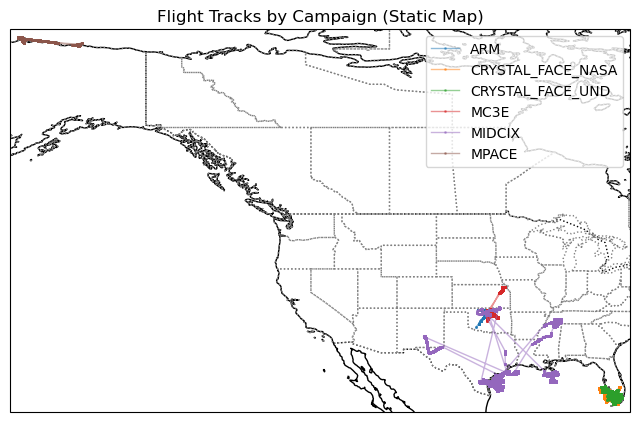

In [17]:
# Set up projection
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': proj})

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')

# Plot each campaign separately
for campaign, group in df.groupby("Campaign"):
    ax.plot(
        group["Longitude [degrees]"], group["Latitude [degrees]"], 
        marker="o", linestyle="-", linewidth=1, markersize=1,
        label=campaign,
        transform=ccrs.PlateCarree(),
        alpha=0.5
    )

# Set extent to fit all data
ax.set_extent([
    df["Longitude [degrees]"].min() - 1,
    df["Longitude [degrees]"].max() + 1,
    df["Latitude [degrees]"].min() - 1,
    df["Latitude [degrees]"].max() + 1
], crs=proj)

ax.legend()
ax.set_title("Flight Tracks by Campaign (Static Map)")
plt.show()

/tmp/tmp.XGte29iYvG/ipykernel_550062/1873100652.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", n)   # tab10 has 10 distinct colors


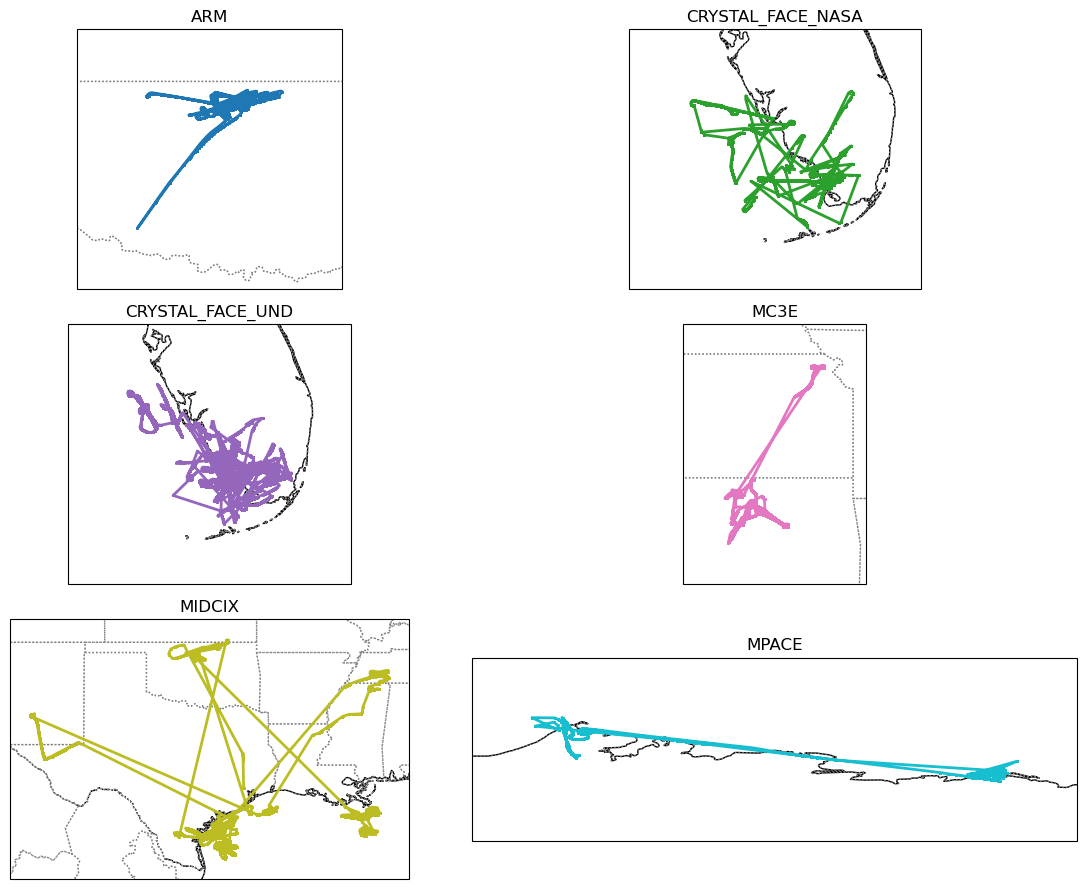

In [21]:
campaigns = df["Campaign"].unique()
n = len(campaigns)

# Pick a colormap and assign one color per campaign
cmap = cm.get_cmap("tab10", n)   # tab10 has 10 distinct colors
colors = {campaign: cmap(i) for i, campaign in enumerate(campaigns)}

fig, axes = plt.subplots(
    nrows=(n+1)//2, ncols=2, figsize=(12, 3*((n+1)//2)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, campaign in zip(axes, campaigns):
    group = df[df["Campaign"] == campaign]

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')

    # Plot campaign track with its assigned color
    ax.plot(
        group["Longitude [degrees]"], group["Latitude [degrees]"],
        marker="o", linestyle="-", linewidth=2, markersize=1,
        color=colors[campaign], label=campaign,
        transform=ccrs.PlateCarree()
    )

    # Zoom to that campaign’s region
    ax.set_extent([
        group["Longitude [degrees]"].min() - 1,
        group["Longitude [degrees]"].max() + 1,
        group["Latitude [degrees]"].min() - 1,
        group["Latitude [degrees]"].max() + 1
    ], crs=ccrs.PlateCarree())
    ax.set_title(campaign)

# Hide unused axes if any
for ax in axes[len(campaigns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

/tmp/tmp.XGte29iYvG/ipykernel_550062/2246555522.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", n)


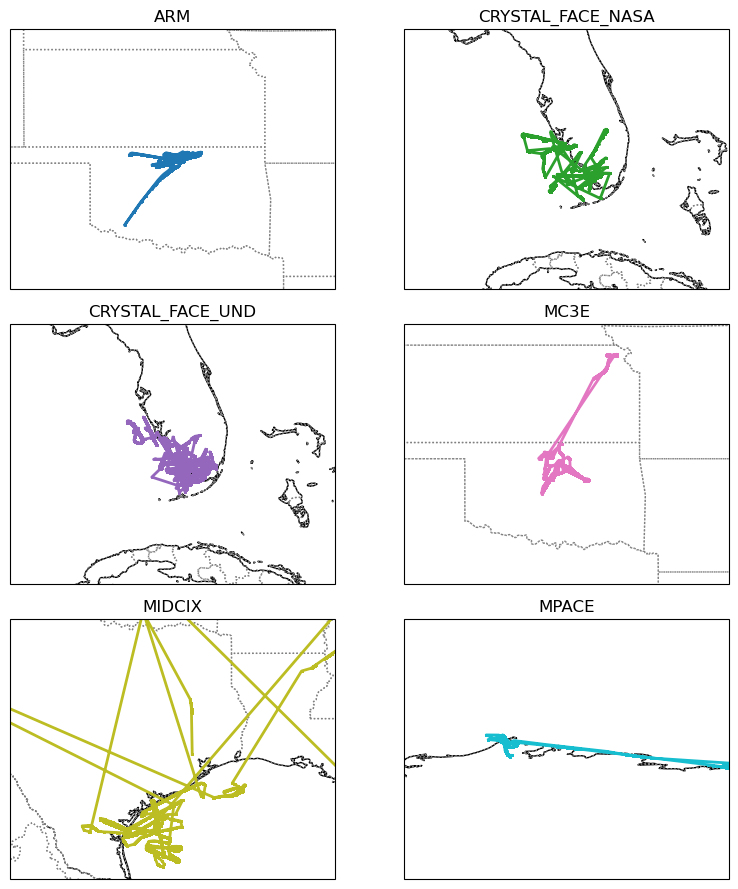

In [53]:
campaigns = df["Campaign"].unique()
n = len(campaigns)

# Pick a colormap and assign one color per campaign
cmap = cm.get_cmap("tab10", n)
colors = {campaign: cmap(i) for i, campaign in enumerate(campaigns)}

# Choose a fixed zoom window size (in degrees)
window_width = 10  # longitude degrees
window_height = 8  # latitude degrees

fig, axes = plt.subplots(
    nrows=(n+1)//2, ncols=2, figsize=(8, 3*((n+1)//2)),  # Reduce width
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, campaign in zip(axes, campaigns):
    group = df[df["Campaign"] == campaign]

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')

    # Plot campaign track with its assigned color
    ax.plot(
        group["Longitude [degrees]"], group["Latitude [degrees]"],
        marker="o", linestyle="-", linewidth=2, markersize=1,
        color=colors[campaign], label=campaign,
        transform=ccrs.PlateCarree(),
        rasterized=True
    )

    # Compute centroid for zoom
    lon_centroid = group["Longitude [degrees]"].mean()
    lat_centroid = group["Latitude [degrees]"].mean()

    # Set extent centered on centroid, with fixed window size
    ax.set_extent([
        lon_centroid - window_width/2,
        lon_centroid + window_width/2,
        lat_centroid - window_height/2,
        lat_centroid + window_height/2
    ], crs=ccrs.PlateCarree())
    ax.set_title(campaign)

# Hide unused axes if any
for ax in axes[len(campaigns):]:
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)  # Even less horizontal space
savedir = '/home/jko/ssl-cpi-analysis/figs/flight-tracks'
savepath = os.path.join(savedir, 'flight-tracks-individual-subplots.pdf')
plt.savefig(savepath, bbox_inches="tight") # save
plt.show()

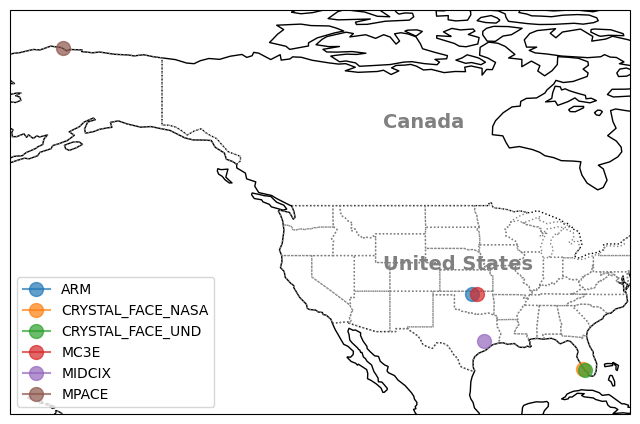

In [50]:
# Set up projection
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': proj})

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')

# Compute and plot centroid for each campaign
for campaign, group in df.groupby("Campaign"):
    lon_centroid = group["Longitude [degrees]"].mean()
    lat_centroid = group["Latitude [degrees]"].mean()

    ax.plot(
        lon_centroid, lat_centroid,
        marker="o", markersize=10,  # big marker
        label=campaign,
        transform=ccrs.PlateCarree(),
        alpha=0.7
    )

# Set extent to fit all data
ax.set_extent([
    df["Longitude [degrees]"].min() - 5,
    df["Longitude [degrees]"].max() + 5,
    df["Latitude [degrees]"].min() - 5,
    df["Latitude [degrees]"].max() + 5
], crs=proj)

# Add country labels
ax.text(-110, 40, "United States", fontsize=14, fontweight='bold', color='gray', transform=ccrs.PlateCarree())
ax.text(-110, 60, "Canada", fontsize=14, fontweight='bold', color='gray', transform=ccrs.PlateCarree())

ax.legend()
savedir = '/home/jko/ssl-cpi-analysis/figs/flight-tracks'
savepath = os.path.join(savedir, 'flight-tracks-us-extent.pdf')
plt.savefig(savepath, bbox_inches="tight") # save
plt.show()

/tmp/tmp.XGte29iYvG/ipykernel_550062/2174505178.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", n)


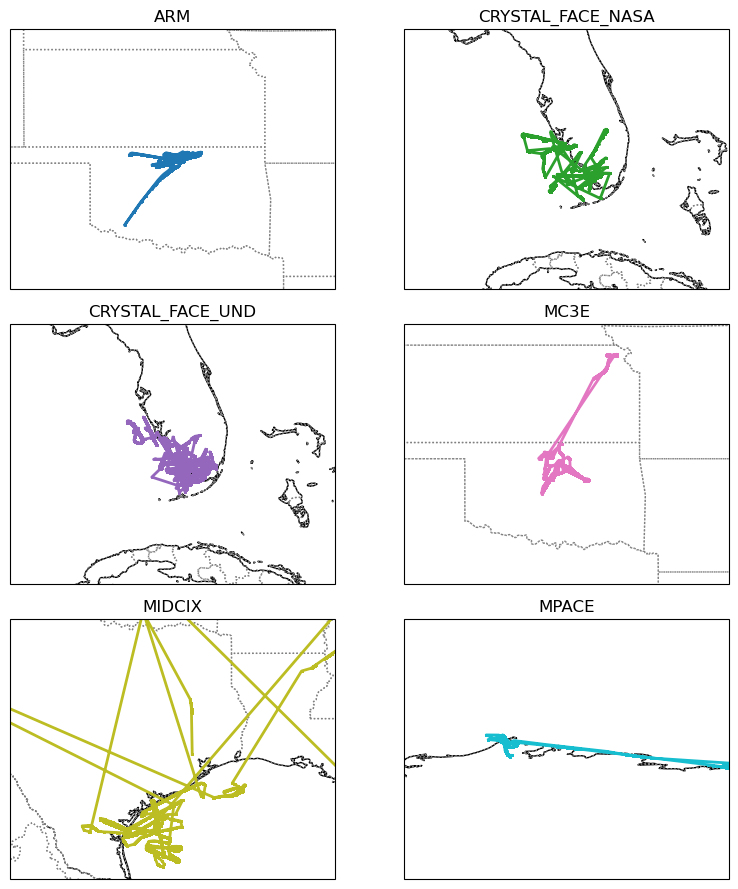

In [54]:
campaigns = df["Campaign"].unique()
n = len(campaigns)

# Pick a colormap and assign one color per campaign
cmap = cm.get_cmap("tab10", n)
colors = {campaign: cmap(i) for i, campaign in enumerate(campaigns)}

# --- Individual subplots for each campaign ---
window_width = 10
window_height = 8

fig, axes = plt.subplots(
    nrows=(n+1)//2, ncols=2, figsize=(8, 3*((n+1)//2)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for ax, campaign in zip(axes, campaigns):
    group = df[df["Campaign"] == campaign]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')
    ax.plot(
        group["Longitude [degrees]"], group["Latitude [degrees]"],
        marker="o", linestyle="-", linewidth=2, markersize=1,
        color=colors[campaign], label=campaign,
        transform=ccrs.PlateCarree(),
        rasterized=True
    )
    lon_centroid = group["Longitude [degrees]"].mean()
    lat_centroid = group["Latitude [degrees]"].mean()
    ax.set_extent([
        lon_centroid - window_width/2,
        lon_centroid + window_width/2,
        lat_centroid - window_height/2,
        lat_centroid + window_height/2
    ], crs=ccrs.PlateCarree())
    ax.set_title(campaign)

for ax in axes[len(campaigns):]:
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
savedir = '/home/jko/ssl-cpi-analysis/figs/flight-tracks'
savepath = os.path.join(savedir, 'flight-tracks-individual-subplots.pdf')
plt.savefig(savepath, bbox_inches="tight")
plt.show()

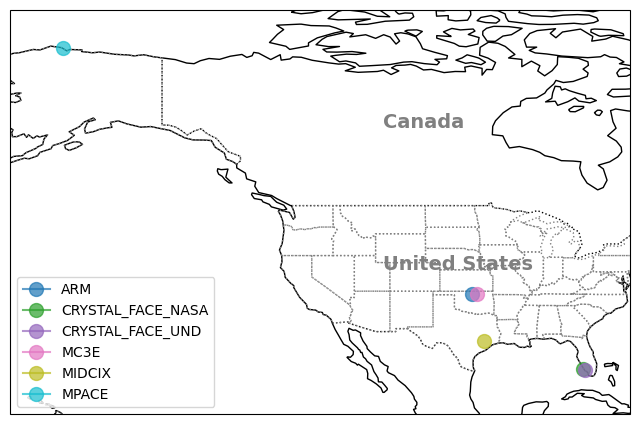

In [55]:
# --- Combined centroid plot ---
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': proj})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')

for campaign, group in df.groupby("Campaign"):
    lon_centroid = group["Longitude [degrees]"].mean()
    lat_centroid = group["Latitude [degrees]"].mean()
    ax.plot(
        lon_centroid, lat_centroid,
        marker="o", markersize=10,
        label=campaign,
        color=colors[campaign],  # <-- use the same color mapping
        transform=ccrs.PlateCarree(),
        alpha=0.7
    )

ax.set_extent([
    df["Longitude [degrees]"].min() - 5,
    df["Longitude [degrees]"].max() + 5,
    df["Latitude [degrees]"].min() - 5,
    df["Latitude [degrees]"].max() + 5
], crs=proj)

ax.text(-110, 40, "United States", fontsize=14, fontweight='bold', color='gray', transform=ccrs.PlateCarree())
ax.text(-110, 60, "Canada", fontsize=14, fontweight='bold', color='gray', transform=ccrs.PlateCarree())

ax.legend()
savepath = os.path.join(savedir, 'flight-tracks-us-extent.pdf')
plt.savefig(savepath, bbox_inches="tight")
plt.show()

# Summary statistics

In [7]:
print(list(df.columns))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '15

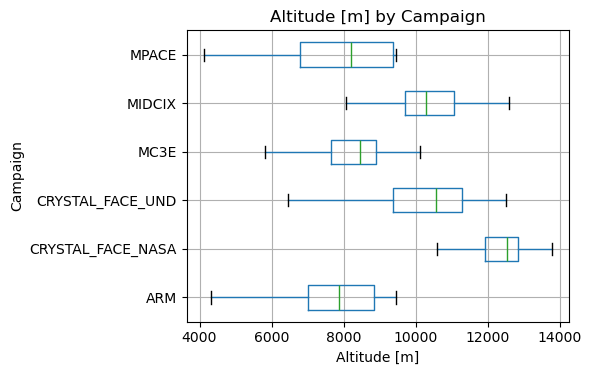

In [30]:
import matplotlib.pyplot as plt
df.boxplot(column='Altitude [m]', by='Campaign', figsize=(6, 4), showfliers=False, vert=False)
plt.title("Altitude [m] by Campaign")
plt.suptitle("")
plt.ylabel("Campaign")
plt.xlabel("Altitude [m]")
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs/campaign-stats'
savepath = os.path.join(savedir, 'alt-by-campaign.pdf')
plt.savefig(savepath, bbox_inches="tight")
plt.show()

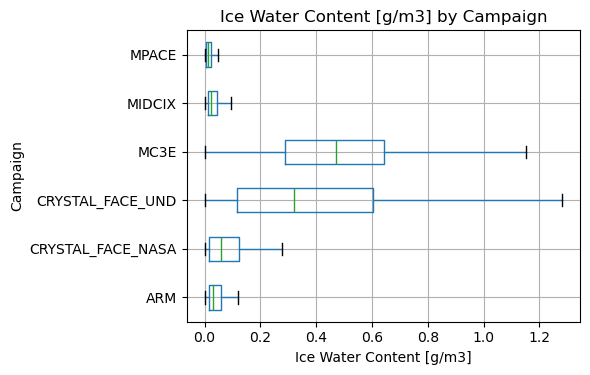

In [31]:
import matplotlib.pyplot as plt

df.boxplot(column='Ice Water Content [g/m3]', by='Campaign', figsize=(6, 4),showfliers=False, vert=False)
plt.title("Ice Water Content [g/m3] by Campaign")
plt.suptitle("")
plt.ylabel("Campaign")
plt.xlabel("Ice Water Content [g/m3]")
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs/campaign-stats'
savepath = os.path.join(savedir, 'iwc-by-campaign.pdf')
plt.savefig(savepath, bbox_inches="tight")
plt.show()

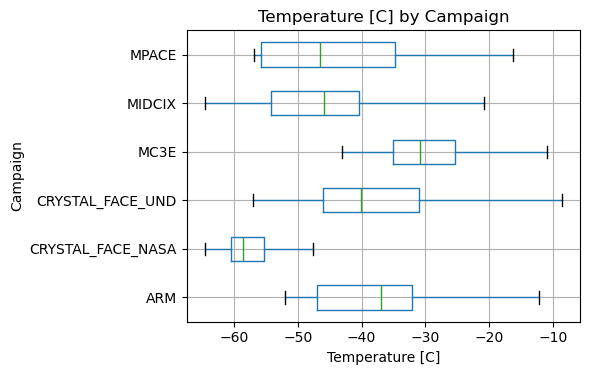

In [32]:
import matplotlib.pyplot as plt

df.boxplot(column='Temperature [C]', by='Campaign', figsize=(6, 4), showfliers=False, vert=False)
plt.title("Temperature [C] by Campaign")
plt.suptitle("")
plt.ylabel("Campaign")
plt.xlabel("Temperature [C]")
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs/campaign-stats'
savepath = os.path.join(savedir, 'temp-by-campaign.pdf')
plt.savefig(savepath, bbox_inches="tight")
plt.show()